In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.base import clone
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import cross_val_score, cross_val_predict
import xgboost as xgb
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')

## Predicting Prospective Customer Risk in Sparse Data Environments

This notebook evaluates two machine learning approaches, Random Forest Classifer (RFC) and Extreme Gradient Boosting (XGB), to predict customer account status using data provided by Maydup Bank plc. The data display a high degree of sparcity with multiple variables exhibiting a large proportion of missing values. Therefore, a key challenge involved careful handling of missing entries. Given the extensive sparcity of the data, the analysis also investigates whether missingness contributed predictive information was conducted. 

Exploratory analysis suggested that missingness may contain predictive information. Therefore, the ability of the classification models to exploit this information, in addition to complete variables, was compared through:

- Model evaluation using cross-validation and test data 
- Feature importance and recursive feature elimination (RFE)

The best performing model was further interpreted through partial dependence analysis of retained variables. Finally, an assessment of probability-threshold classification performance was conducted to improve classification certainty, while also identifying ambiguous records that require additional information.

The objective is to develop a predictive model for customer defaults, providing a decision on whether to accept or decline new applicants.

In [2]:
# Load data
data=pd.read_csv(r'P2data.csv')

# Show first 5 rows
data.head()

,app_id,GOOD,BAD,app_date,disp_income,occ_code,cust_age,time_emp,res_indicator,I_01,...,I_05,D_02,I_06,P_01,S_01,CA_03,CA_02,CA_01,S_02,app_date.1
0,-24,.,.,22-Apr-20,0,SB,19,1,NaN,1,...,13,250,0.000000,.,.,0,0,3,-1,12/02/2035
1,-10,.,.,22-Apr-20,0,SO,29,2,R,1,...,.,.,0.007529,68.859375,1,0,0,3,1,12/02/2035
2,1,0,1,22-Apr-20,0,SO,20,1,P,1,...,10,.,0.023685,56.6484375,1,2,647,3,3,12/02/2035
3,-15,.,.,22-Apr-20,0,SO,16,0,P,.,...,.,.,0.208693,65.328125,.,0,.,5,-1,12/02/2035
4,-19,.,.,22-Apr-20,600,SE,18,0,P,.,...,.,.,0.545007,51.234375,1,1,37,3,2,12/02/2035


### Data Preprocessing

To prepare data for analysis, columns deemed uninformative were removed from the dataset and missing entries were converted to NAs. The data types of each variables were reviewed and converted to string for categorical data and float for numerical data. Lastly, data were filtered for records with GOOD and BAD labels only.

In [3]:
# Drop unuseful columns, also drop BAD since GOOD and BAD are mutually exclusive. 1 - GOOD, 0 - BAD
data=data.drop(['app_id', 'app_date', 'app_date.1', 'BAD'],axis=1)

# Missing entries converted to NAN
data=data.replace('.', np.nan)

# Check data types
print(data.dtypes)


GOOD              object
disp_income        int64
occ_code          object
cust_age           int64
time_emp          object
res_indicator     object
I_01              object
I_02              object
I_03              object
I_04              object
D_01              object
ER_01             object
ER_02             object
I_05              object
D_02              object
I_06             float64
P_01              object
S_01              object
CA_03              int64
CA_02             object
CA_01              int64
S_02               int64
dtype: object


In [4]:
# Convert categorical columns to string and numerical to float
cat_cols=['occ_code', 'res_indicator']

for col in data.columns:
    if col in cat_cols:
        data[col]=data[col].astype('string')
    elif data[col].dtype == 'object':
        data[col]=data[col].astype('float64')

In [5]:
# Filter data to contain only Good/Bad labelled entries 

wLabels=data[(data['GOOD']==0) | (data['GOOD']==1)]

### Exploratory Analysis of Missingness

To explore missingness, first the percentage of missing values in each variable were calculated. Subsequently, the proportion of records labelled GOOD was compared between observations with missing vs present values for variables containing over 50% missingness. 

In [6]:
# Review proportion of NAs in each variable
missing_pct = wLabels.isna().mean()*100

# Convert to dataframe
missing_pct=pd.DataFrame(missing_pct.reset_index())

missing_pct=missing_pct.rename(columns={
    'index':'variable',
    0 :'pct'
})


print(missing_pct)

         variable        pct
0            GOOD   0.000000
1     disp_income   0.000000
2        occ_code   0.000000
3        cust_age   0.000000
4        time_emp  22.373070
5   res_indicator   7.308908
6            I_01  82.090385
7            I_02  79.468105
8            I_03  41.435745
9            I_04  49.804724
10           D_01  75.395202
11          ER_01  37.623210
12          ER_02  42.384229
13           I_05  31.690534
14           D_02  88.580993
15           I_06   0.000000
16           P_01   8.480565
17           S_01  57.950530
18          CA_03   0.000000
19          CA_02  51.794681
20          CA_01   0.000000
21           S_02   0.000000


Six columns display a high proportion of missing (> 50 %) values. In particular, I_01, I_02, D_01, and D_02 exhibit greater than 75% missing values.

In [7]:
# For variables with pct of NAs greater than 50, check importance in assignment of good or bad

# Assign variables with pct > 50 to list
na_list=missing_pct.loc[missing_pct['pct']>50, 'variable'].to_list()

# For each variable compare proportion of good in present vs missing rows
for var in na_list:
    mask=wLabels[var].notna()
    pct_present = wLabels.loc[mask, 'GOOD'].mean()
    pct_missing = wLabels.loc[~mask,'GOOD'].mean()
    
    print(var, pct_present, pct_missing, pct_present-pct_missing)

I_01 0.5898234683281413 0.666062528318985 -0.0762390599908438
I_02 0.5887681159420289 0.6688509244090802 -0.08008280846705129
D_01 0.564625850340136 0.6810557474099654 -0.11642989706982942
D_02 0.5960912052117264 0.6596682762964519 -0.06357707108472543
S_01 0.5869084475895622 0.6999358151476252 -0.11302736755806297
CA_02 0.6257716049382716 0.6771992818671454 -0.051427676928873844


Given that there is a difference in proportion considered good between present and missing groups for each variable, then missingness might be informative. Particularly, in variables D_01 and S_01 which both suggest a decrease in proportion good when values are present by approximately 11-12%.

### Model Evaluation: Random Forest Classifier

#### Baseline evaluation
To evaluate classification models, an initial majority class model was defined for comparison. The data were then divided into train and test sets. One training set included high-missingness variables, while in a second these were removed to assess influence of missingness on predictive performance. 
#### Missingness handling
According to sklearn documentation, the RFC supports native handlng of missing values (NaNs). The model learns how missing observations should be routed dring tree splitting (scikit-learn documentation). Therefore, instead of imputing missing data, NAs were retained. 
#### Model comparison and optimisation
A baseline model was fit to the full feature set and evaluated using 5-fold cross-validation and performance on test data. Subsequently:
- model performance was compared where high-missingness variables were removed individually 
- a reduced feature-set model, where all high missingness variables were removed, was evaluated
- hyperparameter tuning was performed
- feature imporances were reviewed
- recursive feature elimination was applied to evaluate model performance under reduced model complexity 

In [8]:
# Majority class model

print('Majority class baseline accuracy:',round(np.mean(wLabels['GOOD'] ==1),2))

Majority class baseline accuracy: 0.65


Generally, model performance will be compared against a majority class baseline, which acheives approximately 65% accuracy by always predicting the most frequent class. In this case, the majority class is an account being GOOD.

In [9]:
# Encode data with missing identifier to test usefulness of variables with high missing percentage

df = wLabels.copy()

# Encode categoricals
cat_cols = ['occ_code', 'res_indicator']
df=pd.get_dummies(df, columns=cat_cols, drop_first=True)

y=df['GOOD']
X=df.drop(columns=['GOOD'])

In [10]:
# Train test split - for full dataset
X_train, X_test, y_train, y_test = train_test_split(X,y.astype(int), test_size=0.2, random_state=15)

# Define train and test set with absent high missingness variables
XA_train=X_train.copy()
XA_train = XA_train.drop(columns = na_list)

XA_test=X_test.copy()
XA_test=XA_test.drop(columns = na_list)

In [11]:
# Define baseline RFC model
RFCmodel=RFC(random_state=15)

# Cross-validate
baselineRF_score=cross_val_score(RFCmodel, X_train, y_train, cv=5).mean()

# Print baseline cv score
print('Baseline', baselineRF_score)

Baseline 0.6919360937795423


The model only modestly improves prediction above the majority class baseline. However, this does suggest that features offer some additional predictive value to the model.  

To test whether  high missingness variables influence model performance, each is dropped alone and model performance is compared to baseline RFC model.

In [14]:
# Define function to compare baseline model with model after dropping high missing variables
def compare_missing(Xtrain, ytrain, model, baseline_score):
    resultsRF={}
    for var in na_list:
        X_temp = Xtrain.drop(columns=[var])
        # Cross-validation of each model after dropping high missingness variable
        score = cross_val_score(model, X_temp, ytrain, cv=5).mean()
        # Record change in score
        resultsRF[var] = score - baseline_score

    print(pd.Series(resultsRF).sort_values(ascending=False).round(6))

In [15]:
# Display comparison of each RFC model after dropping separate high missing variables with baseline
compare_missing(X_train, y_train, RFCmodel, baselineRF_score)

D_02     0.007672
I_01     0.004880
I_02     0.003952
S_01    -0.000933
D_01    -0.002558
CA_02   -0.003724
dtype: float64


Individually removing each high-missingness variable resulted in only small changes in cross-validation accuracy, suggeting that no single high-missingness variable was critical to RFC performance. Next check whether it is possible to improve model through hyperparameter tuning. 

In [16]:
# Identify best random forest classifier model for data and evaluate

# Hyperparameter tuning
param_dist={
        'n_estimators': randint(100,500),
        'max_depth': randint(3, 15),
        'min_samples_split': randint(2,10),
        'min_samples_leaf': randint(1,5)
        }

# Select array of hyperparamters
rand_search=RandomizedSearchCV(
            RFC(), param_distributions=param_dist,
            n_iter=10, cv=5, scoring='accuracy', random_state=15)

# Fit best parameters to data
rand_search.fit(X_train,y_train)

# Best fitted model
best_rf=rand_search.best_estimator_

In [18]:
# Evaluate with all columns

score_bestRF = cross_val_score(best_rf, X_train, y_train, cv=5).mean()

print(f'RFC cross-validation score after hyperparameter tuning: {score_bestRF}')

RFC cross-validation score after hyperparameter tuning: 0.6986743375739405


Hyperparameter tuning do not improve model greatly above baseline cross-validation score.  

Tuning does not appear to have a large effect on model performance. These results suggest that increasing model complexity has limited effect on performance. Therefore, the model is constrained by the available data rather than the model parameters.

In [17]:
# Evaluate after dropping high missingness columns

score_reduced = cross_val_score(best_rf, XA_train, y_train, cv=5).mean()
print(score_reduced)

0.6837973692029278


Removing high missingness variables together resulted in a drop in performance. Given the relative stability of model performance across evaluations, missingness might be informative when high missingness variables are considered together.

In [44]:
# Define function to extract importances from model

def model_importances(Xtrain, model):
    # Make series of model features and sort in descending order
    importances=pd.Series(model.feature_importances_,Xtrain.columns).sort_values(ascending=False)
    # Sum importances of occ_code dummies
    occ_importance=importances[importances.index.str.contains('occ_code')].sum()
    # Make dataframe of importances 
    importances=pd.DataFrame(importances.reset_index())
    # Print dataframe and summed occ_code importances
    print(importances)
    print()
    print('Sum of occ_code dummies:', occ_importance)

In [23]:
#Feature importances for best RFC model fit to all variables
best_rf=best_rf.fit(X_train, y_train)

model_importances(X_train, best_rf)

              index         0
0          time_emp  0.110456
1              I_06  0.084640
2              P_01  0.081325
3             ER_01  0.071048
4          cust_age  0.069364
5              D_01  0.067542
6              I_05  0.063111
7              I_03  0.055459
8             CA_02  0.039866
9             ER_02  0.039368
10      disp_income  0.035800
11             S_02  0.034875
12             I_02  0.031675
13             S_01  0.028740
14             D_02  0.026304
15             I_04  0.019014
16            CA_01  0.017537
17            CA_03  0.013696
18             I_01  0.013320
19  res_indicator_P  0.011172
20  res_indicator_R  0.010983
21      occ_code_SO  0.009732
22      occ_code_SB  0.008988
23      occ_code_SA  0.008139
24      occ_code_SM  0.007331
25      occ_code_SD  0.006546
26      occ_code_SC  0.006500
27      occ_code_SL  0.005165
28      occ_code_SF  0.004744
29      occ_code_SK  0.004502
30      occ_code_SE  0.004157
31      occ_code_SH  0.003781
32      oc

A review of model feature importances indicate that variables time_emp, P_01, and I_06 contribute relatively strongly to classification perforamance. In addition, summing the contributions of occ_code, show that it ranks relatively highly, as does high missingness variable D_01. However, there is no one variable that exhibits particularly high importance, dominating model performance, suggesting the model relies on information distributed across multiple features.

In [36]:
# Define function for feature selection
def feature_selection(Xtrain, ytrain, model, n_features):

    pipeline = Pipeline([('rfe', RFE(clone(model), n_features_to_select=n_features, step=5)), ('model', clone(model))])

    cv_score=cross_val_score(pipeline, Xtrain, ytrain, cv=5, scoring='accuracy', n_jobs=-1).mean()
    
    pipeline.fit(Xtrain,ytrain)

    selected_features = Xtrain.columns[
    pipeline.named_steps['rfe'].support_].to_list()

    return selected_features,cv_score

In [38]:
# Application of aggressive recursive feature elimination to identify whether dropping multiple variables has an impact on performance

featuresRF,cv_score=feature_selection(X_train, y_train, best_rf, 5)
print(f'retained features {featuresRF}, model accuracy = {round(cv_score,5)}')

retained features ['time_emp', 'ER_01', 'I_05', 'I_06', 'P_01'], model accuracy = 0.66821


Simplified model performs worse than the model fitted to the full feature set. In addition, none of the high missingness variables are retained following aggressive feature selection. It appears that the random forest model relies mainly on more complete variables for prediction.

### Model Evaluation: Extreme Gradient Boosting

#### Missingness handling
Extreme gradient boosting (XGB) supports missing values by default (XGBoost documentation). In tree algorithms, optimal split direction based on missing values are learned during training. Moreover, unlike Random Forest where trees are built independently, in XGBoost trees are sequential allowing subsequent trees to learn from previous prediction errors.
#### Model comparison and optimisation
The proceedural steps applied to the RFC model were also conducted for the XGB model. Addtionally: 
- feature importances of the simplified model were reviewed
- partial dependence relationships of the retained variables were investigated
- chi-square tests were applied to evaluate whether high-missingness variables variables, retained in the model, contained predictive information

In [39]:
# Fit baseline xgboost model to data

XGBmodel=xgb.XGBClassifier(random_state=15)

baselineXGB_score=cross_val_score(XGBmodel, X_train, y_train, cv=5).mean()

print('Baseline', baselineXGB_score)

Baseline 0.6849585392863895


In [22]:
# Display comparison of each XGB model after dropping separate high missing variables with baseline
compare_missing(X_train, y_train, XGBmodel, baselineXGB_score)


S_01     0.008602
I_01     0.007443
D_02     0.004418
CA_02   -0.001161
I_02    -0.003720
D_01    -0.004186
dtype: float64


As with Random Forest, there appears little little influence of each high missingness variable individually on XGBoost model performance.

In [40]:
# Hyperparameter tuning for xgboost

# Hyperparameter tuning
param_dist={
        'n_estimators': randint(100,600),
        'max_depth': randint(2, 10),
        'learning_rate': uniform(0.01,0.2),
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'min_child_weight': randint(1,10),
        'gamma': uniform(0,5),
        'reg_alpha':uniform(0,5),
        'reg_lambda': uniform(0,1)
        }

# Select array of hyperparamters
rand_search=RandomizedSearchCV(
            xgb.XGBClassifier(), param_distributions=param_dist,
            n_iter=50, cv=5, scoring='accuracy', 
            n_jobs=-1, random_state=15)

# Fit best parameters to data
rand_search.fit(X_train,y_train)

# Best fitted model
best_xgb=rand_search.best_estimator_

In [32]:
# Cross-validation after hypertuning and apply to all variables
score_bestXGB = cross_val_score(best_xgb, X_train, y_train, cv=5).mean()
print(score_bestXGB)


0.7054169030062394


Hyperparameter tuning improved accuracy performance marginally above baseline.

In [41]:
# Cross-validation after dropping high missingness variables 
score_reducedXGB = cross_val_score(best_xgb, XA_train, y_train, cv=5).mean()
print(score_reducedXGB)

0.6868187343002997


Dropping high missingness variables results in a decrease in performance. 

In [36]:
# Display feature importances for XGboost model

best_xgb=best_xgb.fit(X_train, y_train)

model_importances(X_train, best_xgb)

              index         0
0          time_emp  0.099039
1          cust_age  0.066091
2              D_01  0.043420
3             CA_02  0.040273
4             ER_01  0.039835
5              S_02  0.036157
6             CA_01  0.035235
7              S_01  0.034780
8              I_06  0.034087
9   res_indicator_P  0.033785
10      disp_income  0.032460
11      occ_code_SM  0.031347
12  res_indicator_R  0.031000
13            ER_02  0.030405
14             I_04  0.026785
15      occ_code_SK  0.026683
16             P_01  0.024982
17             D_02  0.024703
18      occ_code_SO  0.024571
19             I_05  0.024083
20      occ_code_SB  0.023602
21             I_03  0.022762
22      occ_code_SC  0.022550
23      occ_code_SL  0.022061
24             I_02  0.021889
25      occ_code_SA  0.020862
26            CA_03  0.020163
27             I_01  0.019475
28      occ_code_SD  0.018621
29      occ_code_SH  0.017539
30      occ_code_SF  0.017433
31      occ_code_SN  0.017310
32      oc

Ranking the feature importances for XGBoost shows that the model more highly relies on a slightly different set of variables compared to random forest. Summing the importances of occ_code dummy variables indicates that the occupation category contributes relatively strongly to model predictions, accounting for approximately 26% of the total feature importance. In addition, multiple high missingness variables rank highly, including D_01, CA_02, and S_01. 

In [81]:
# Application of aggressive recursive feature selection to identify whether dropping multiple variables has an impact on performance
featuresXGB, cv_score=feature_selection(X_train, y_train, best_xgb, 5)
print(f'retained features {featuresXGB}, model accuracy = {round(cv_score,5)}')


retained features ['cust_age', 'time_emp', 'D_01', 'ER_01', 'CA_02'], model accuracy = 0.69077


Simplified model appears to perform marginally less than model fitted to all variables. Interestingly, no occupation variables were retained following feature selection, suggesting that other variables included in the simplified model might provide overlapping information. However, this model displays the best cross-validation performance. 

In [46]:
# Rank importances of simplified model
simplified_xgb=best_xgb.fit(X_train[featuresXGB], y_train)
model_importances(X_train[featuresXGB], simplified_xgb)

      index         0
0  time_emp  0.322907
1  cust_age  0.217337
2      D_01  0.166085
3     ER_01  0.164453
4     CA_02  0.129218

Sum of occ_code dummies: 0.0


A review of the importances of the simplified model shows that the model relies largely on time_emp and cust_age for predictions. However, D_01 ranks relatively highly in feature importance, while CA_02 remains within the selected feature subset. Given these variables contain approximately 75% and 50% missing entries, this provides further evidence that missingness may be associated with predictive information.

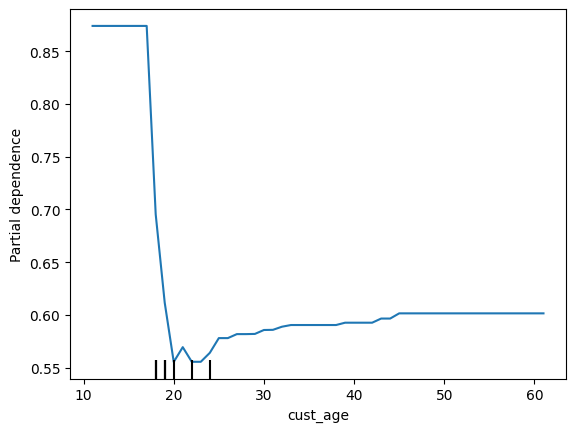

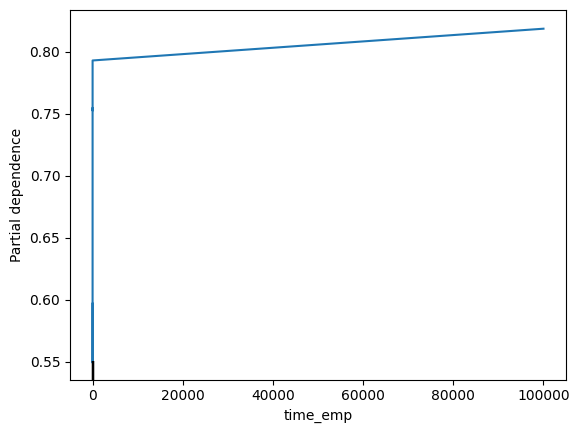

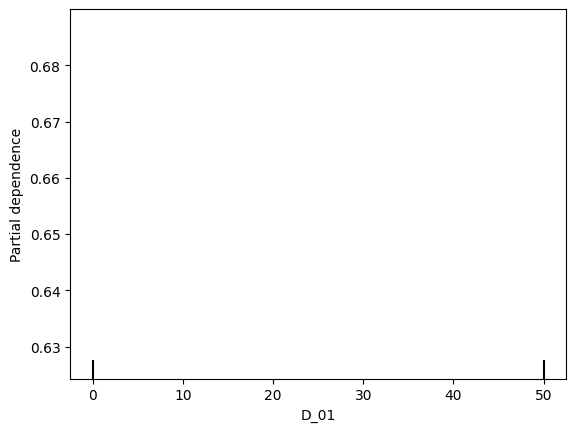

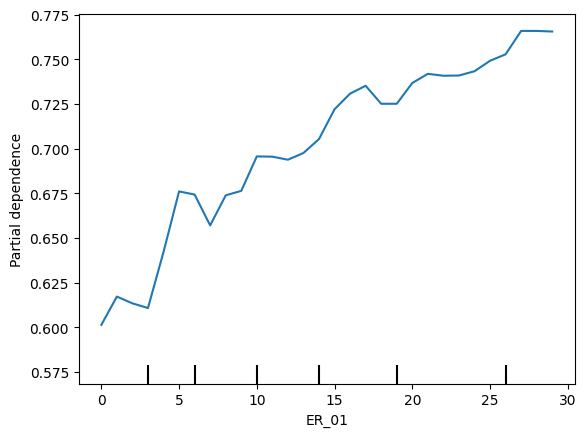

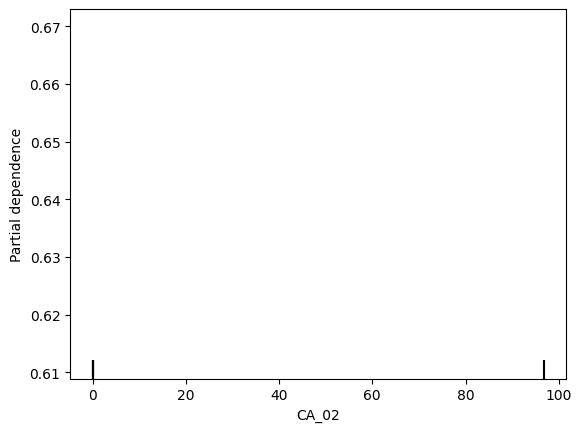

In [47]:
# Evaluation of the partial dependences determine how they influence the model predictions

for col in featuresXGB:
    PartialDependenceDisplay.from_estimator(simplified_xgb, X_train[featuresXGB], [col])
    plt.savefig(f'pdp_{col}.png', dpi=300, bbox_inches='tight')

Variable cust_age shows a very rapid decline between 15 and 20, followed by a gradual increase as cust_age increases towards 60. This suggests increasing age increases probability of model prediction being GOOD.
Time_emp displays an initial rapid increase followed by a gradual increase from 0 to 100000. This is indicative that there is an increasing proBabability of the model predicting GOOD as time_emp increases.
ER_01 displays a general increasing gradient, indicating that it is associated with an increasing probability of the model predicting GOOD.


In [48]:
# Check strength of missing vs. not missing for D_01

X_train['D_01_missing'] = X_train['D_01'].isna().astype(int)

pd.crosstab(X_train['D_01_missing'], y)

GOOD,0.0,1.0
D_01_missing,,
0,459,578
1,1050,2214


In [49]:
X_train['CA_02_missing'] = X_train['CA_02'].isna().astype(int)

pd.crosstab(X_train['CA_02_missing'], y)

GOOD,0.0,1.0
CA_02_missing,,
0,776,1266
1,733,1526


Finally, to evaluate whether missingness carries predictive information, normalized contingency tables were constructed for high missingness variables. For D_01, observations with missing values displayed a higher proportion of accounts identified as GOOD (approximately 68%), while presence of values showed fewer classifications identified as GOOD (approximately 56%). A similar pattern can be observed for variable CA_02.

In [50]:
from scipy.stats import chi2_contingency

d01_table=pd.crosstab(X_train['D_01_missing'], y)

chi2, p, dof, expected= chi2_contingency(d01_table)

print(chi2,p)

50.003356673688984 1.5348319451127321e-12


In [51]:
n=d01_table.sum().sum()
phi=np.sqrt(chi2/n)
print(phi)

0.10782385580821441


Chi-squared test for independence showed that there is a significant association between missingness in D_01 and account classification (p<0.001) however, effect size is approximately 0.1, therefore although the effect is modest, missingness in D_01 contributes predictive information to the model. 

In [52]:
ca02_table=pd.crosstab(X_train['CA_02_missing'], y)

chi2, p, dof, expected= chi2_contingency(ca02_table)

print(chi2,p)

14.283106392210994 0.00015727002938623982


In [53]:
n=ca02_table.sum().sum()
phi=np.sqrt(chi2/n)
print(phi)

0.05762708001968527


Chi-squared test for independence showed that there is a significant association between missingness in CA_02 and account classification (p<0.001) however, effect size is approximately 0.06, therefore although the effect is modest, missingness in CA_02 contributes predictive information to the model. 

In [54]:
# Drop missing indicator variables

X_train=X_train.drop(['D_01_missing','CA_02_missing'], axis=1)

### Developing a predictive final model

#### Final model selection
To select a final model, RFE-selected features were added incrementally to the five-feature XGB model until cross-validation accuracy exceeded 0.70. Model performance was subsequently assessed using test data.
#### Probability thresholds
Thresholds for GOOD, BAD and PASS were selected by identifying a suitable compromise between classification accuracy and coverage on training data.
#### Assessing missingness
Data were grouped by GOOD, BAD and PASS probability thresholds to assess whether patterns of missingness differed between classification groups.
#### Final model evaluation
The performance of the final model along with the selected thresholds was assessed on test data to evaluate generalization performance.

In [56]:
# Stepwise incremental recursive feature selection
for n_features in range(5,20):
    featuresFinal,cv_score=feature_selection(X_train, y_train, best_xgb, n_features)
    if cv_score > 0.70:
        break

In [59]:
# Evaluate cross validation performance of model fit to the feature set
print(cv_score)

0.7042578937417281


In [58]:
print(featuresFinal)

['disp_income', 'cust_age', 'time_emp', 'D_01', 'ER_01', 'ER_02', 'S_01', 'CA_02', 'CA_01', 'res_indicator_P', 'res_indicator_R']


The final model is composed of eleven features. Three of the variables are high-missingness variables exhibiting > 50% missingness, with S_01 and D_01 displaying > 70% missingness.

Classification thresholds were applied to the predicted probabilities derived from the model after fitting to the reduced-feature training data.

In [70]:
 # Probabilities extracted from the final model predictions on the training set
pipeline = Pipeline([('rfe', RFE(clone(best_xgb), n_features_to_select=len(featuresFinal), step=5)), ('model', clone(best_xgb))])

cv_probs=cross_val_predict(pipeline, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1)[:,1]

In [71]:
def thresholds(X, y, features, probs, good_thresh, bad_thresh): 
    # Dataframe of selected features, probabilities and predictions based on cutoff

    prob_results=X[features].copy()
    prob_results['actual']=y
    prob_results['prob_good']=probs

    # Assign predictions GOOD, BAD and PASS based on probability cutoffs
    predictions=[]
    for i,row in prob_results.iterrows():
        if row['prob_good'] >= good_thresh:
            predictions.append('GOOD')
        elif row['prob_good'] <= bad_thresh:
            predictions.append('BAD')
        else:
            predictions.append('PASS')

    prob_results['predictions'] = predictions
    return prob_results

In [72]:
def test_thresh_preds(prob_results):
    # Dataframe including GOOD and BAD predicitons only

    subset = prob_results[prob_results['predictions'] != 'PASS']

    # Generate binary 0 - BAD, 1 - GOOD
    binary=[]
    for i, row in subset.iterrows():
        if row['predictions']=='GOOD':
            binary.append(1)
        else:
            binary.append(0)
    subset['binary_GOOD']=binary
    
    accuracy=accuracy_score(subset['actual'], subset['binary_GOOD'])
    precision=precision_score(subset['actual'], subset['binary_GOOD'], average='macro')
    recall=recall_score(subset['actual'], subset['binary_GOOD'], average='macro')

    return round(accuracy,4), round(precision,4), round(recall,4)

In [73]:
# Application of thresholds 
prob_results = thresholds(X_train, y_train, featuresFinal, cv_probs, 0.70, 0.40)
# Cross-validation performance, including accuracy, precision and recall, on training data
accuracy, precision, recall = test_thresh_preds(prob_results)

print(f'Final XGB model with applied thresholds cross-validation performance: accuracy = {accuracy}, precision = {precision}, recall = {recall}')

Final XGB model with applied thresholds cross-validation performance: accuracy = 0.7864, precision = 0.7351, recall = 0.6956


In [74]:
# Print coverage
print('Coverage:', round(len(prob_results[(prob_results['predictions']=='GOOD') | (prob_results['predictions']=='BAD')])/len(prob_results['predictions']),2))

Coverage: 0.59


The application of probability thresholds improved classification accuracy, precision and recall for retained predictions. However, prediction coverage was approximately 59%, where the remaining 41% of records were classified as PASS.

Subsequently, classification probability thresholds were used to evaluate whether missingness patterns differed between the GOOD, BAD and PASS prediction groups.

In [75]:
# Review proportion of NAs in each variable for dataframe limited to selected features and GOOD predictions
missing_pctGOOD = prob_results[prob_results['predictions']=='GOOD'].isna().mean()*100

# Convert to dataframe
missing_pctGOOD=pd.DataFrame(missing_pctGOOD.reset_index())

missing_pctGOOD=missing_pctGOOD.rename(columns={
    'index':'variable',
    0 :'pct'
})

# Display percentage missingness of each variable present in predicted-GOOD subset
print(missing_pctGOOD[missing_pctGOOD['variable'].isin(featuresFinal)])

           variable        pct
0       disp_income   0.000000
1          cust_age   0.000000
2          time_emp  42.047714
3              D_01  87.773360
4             ER_01  32.355865
5             ER_02  39.960239
6              S_01  72.664016
7             CA_02  62.276342
8             CA_01   0.000000
9   res_indicator_P   0.000000
10  res_indicator_R   0.000000


In [76]:
# Review proportion of NAs in each variable for dataframe limited to selected features and BAD predictions
missing_pctBAD = prob_results[prob_results['predictions']=='BAD'].isna().mean()*100

# Convert to dataframe
missing_pctBAD=pd.DataFrame(missing_pctBAD.reset_index())

missing_pctBAD=missing_pctBAD.rename(columns={
    'index':'variable',
    0 :'pct'
})

# Display percentage missingness of each variable present in predicted-BAD subset
print(missing_pctBAD[missing_pctBAD['variable'].isin(featuresFinal)])

           variable        pct
0       disp_income   0.000000
1          cust_age   0.000000
2          time_emp   1.869159
3              D_01  62.616822
4             ER_01  61.869159
5             ER_02  59.439252
6              S_01  34.392523
7             CA_02  50.654206
8             CA_01   0.000000
9   res_indicator_P   0.000000
10  res_indicator_R   0.000000


In [77]:
# Review proportion of NAs in each variable for dataframe limited to selected features and PASS predictions
missing_pctPASS = prob_results[prob_results['predictions']=='PASS'].isna().mean()*100

# Convert to dataframe
missing_pctPASS=pd.DataFrame(missing_pctPASS.reset_index())

missing_pctPASS=missing_pctPASS.rename(columns={
    'index':'variable',
    0 :'pct'
})

# Display percentage missingness of each variable present in predicted-PASS subset
print(missing_pctPASS[missing_pctPASS['variable'].isin(featuresFinal)])

           variable        pct
0       disp_income   0.000000
1          cust_age   0.000000
2          time_emp   6.271380
3              D_01  66.305587
4             ER_01  36.316990
5             ER_02  39.794755
6              S_01  48.574686
7             CA_02  41.904219
8             CA_01   0.000000
9   res_indicator_P   0.000000
10  res_indicator_R   0.000000


This analysis showed that the identified high-missingness variables exhibited a greater proportion of missing values within high-certainty GOOD predictions compared to BAD predictions. Moreover, PASS predictions generally displayed intermediate levels of missingness.

Evaluation of final model and probability thresholds on test data.

In [78]:
# Fit final model
final_xgb=best_xgb.fit(X_train[featuresFinal], y_train)

# Extract test probabilities from final model fit to test data
test_probs= final_xgb.predict_proba(X_test[featuresFinal])[:,1]

In [80]:
# Apply thresholds 
prob_results = thresholds(X_test, y_test, featuresFinal, test_probs, 0.70, 0.40)
# Final performance on test data
accuracy, precision, recall = test_thresh_preds(prob_results)

print(f'Final XGB model with applied thresholds test performance: accuracy = {accuracy}, precision = {precision}, recall = {recall}')

Final XGB model with applied thresholds test performance: accuracy = 0.7783, precision = 0.7248, recall = 0.6959


The final model appears to generalize well to unseen data, with test performance remaining consistent with cross-validation accuracy, precision and recall estimates.